In [1]:
from IPython.display import HTML
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Montserrat:ital,wght@0,300;0,400;0,700;1,400&display=swap');
</style>
"""))

<h1 style="color:teal; font-size:45px; font-family:'Montserrat', sans-serif; font-weight:bold; margin-bottom: 5px;">
Notebook SENTINEL-2 - PIR Rio Tinto
</h1>

<p style="color:#444; font-size:12px; font-family:'Montserrat', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Data : EnMAP Image
</p>
<p style="font-size:16px; font-family:'Montserrat'; color:#34495e; margin-top: 0px; text-align: right;">
HOSSEINI Arman, STAUB Guillaume
</p>

<div style="margin-top: 30px;">
</div>
<div style="background-color: #ecf5fb; border-left: 15px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
<h2 style="color: teal; ">Index</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li style="margin-bottom: 8px;">
            <a href="#00" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">0.</span>
                <span style="color: #2c3e50; font-weight: 600;">Imports</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#10" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.</span>
                <span style="color: #2c3e50; font-weight: 600;">Visualization</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#20" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">2.</span>
                <span style="color: #2c3e50; font-weight: 600;">Direct K-Means</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#30" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.</span>
                <span style="color: #2c3e50; font-weight: 600;">Pixel-by-Pixel AutoEncoder with K-Means on latent-space</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#40" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.</span>
                <span style="color: #2c3e50; font-weight: 600;">2D Convolutional AutoEncoder with K-Means on latent space</span>
            </a>
        </li>
    <!--
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
    </ul>
    -->
</ul>
</div>
<div id="00"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    0. Imports
</h2>

In [2]:
import time
import os

import sys, random, re

import torch; import torch.nn as nn; import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader, Subset

import rasterio as rio; from rasterio.plot import reshape_as_image, reshape_as_raster
import numpy as np; import pandas as pd
from sklearn.preprocessing import StandardScaler; from sklearn.cluster import KMeans; from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
import matplotlib.pyplot as plt; import matplotlib.colors as colors; from matplotlib.colors import ListedColormap
from matplotlib import cm
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster; from kneed import KneeLocator
import xml.etree.ElementTree as ET

<div id="10"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    1. Visualization

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We start by applying masks to the SENTINEL-2 image and display them.

In [3]:
def apply_mask(image_path, mask_path):
    # --- Image ---
    raster_img = rio.open(image_path)
    arr_img = reshape_as_image(raster_img.read())  # (m, n, l)

    # On ne met NaN que pour les pixels hors [0,1] (les zéros restent)
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    arr_img[~mask_norm] = np.nan

    image = reshape_as_raster(arr_img)
    l, m, n = image.shape

    X = image.reshape(l, -1).T
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Masque ---
    with rio.open(mask_path) as src:
        mask_band = src.read(1)                 # (m, n)
    mask_soil = (mask_band > 0).astype(np.uint8)  # 1 = zone affichée, 0 = fond

    mask_soil_elargi = mask_soil[:, :, np.newaxis]          # (m, n, 1)
    vec_new = np.repeat(mask_soil_elargi, X_scaled.shape[1], axis=2)  # (m, n, l)

    X_scaled_soil = X_scaled.reshape(m, n, l) * vec_new

    # --- RGB ---
    RED   = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE  = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)   # (m, n, 3)

    # --- Normalisation canal par canal ---
    min_val = np.nanmin(rgb, axis=(0, 1))
    max_val = np.nanmax(rgb, axis=(0, 1))
    scale = max_val - min_val
    scale[scale == 0] = 1
    rgb_norm = (rgb - min_val) / scale

    # --- FORCER le fond à noir ---
    # mask_soil == 0 -> fond, on les met à (0,0,0)
    fond = (mask_soil == 0)           # (m, n) bool
    rgb_norm[fond] = 0.0              # broadcasting sur la 3ème dimension

    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()

    return rgb_norm, fond

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
SENTINEL-2 image with mask to only display the soil:

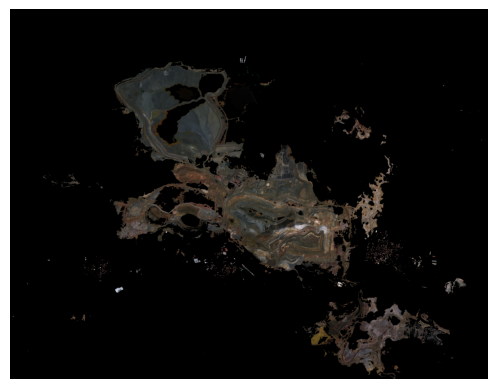

In [4]:
soil_only, fond_soil = apply_mask(r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img',
                       r"./mask_total_soil_VSWIR_10m.img")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
EnMAP image with mask to only display the vegetation:

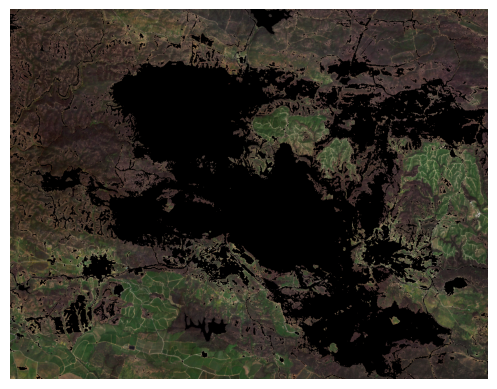

In [5]:
vegetation_only, fond_vegetation = apply_mask(r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img',
                             r"./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_mask_veg.img")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply the vegetation mask and set all external pixels to the mean of the scaled vegetation pixel values:

In [6]:
image_path = r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

veg_mask_2d = (vegetation_only[:, :, 0] != 0)  # prendre la première bande uniquement
veg_mask_1d = veg_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
veg_pixels = pixels[veg_mask_1d]             # (N_veg, l) → uniquement végétation

scaler = StandardScaler()
X_scaled_veg = scaler.fit_transform(veg_pixels)
#print(X_scaled_veg.shape)
img_scaled_veg_complete = pixels.copy()
img_scaled_veg_complete[veg_mask_1d] = X_scaled_veg
img_scaled_veg_complete[~veg_mask_1d] = np.mean(X_scaled_veg)

<div id="20"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    2. Direct K-Means 

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We will use the knee criterion to guess the number of clusters we want for vegetation, soil and "other" separately:

<div id="21"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.1 Vegetation (and partial ARI)

In [7]:
def compute_optimal_k(X_scaled):

    inertias = []
    K_range = range(2, 20, 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        #print("Done")
    
    plt.plot(K_range, inertias, marker='o')
    plt.xlabel('Number of clusters K')
    plt.ylabel('Inertia (Sum of distances)')
    plt.title('Knee criterion')
    plt.show()
    
    knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
    optimal_k = knee.knee
    
    print(f"optimal value: k = {optimal_k}")
    
    return optimal_k

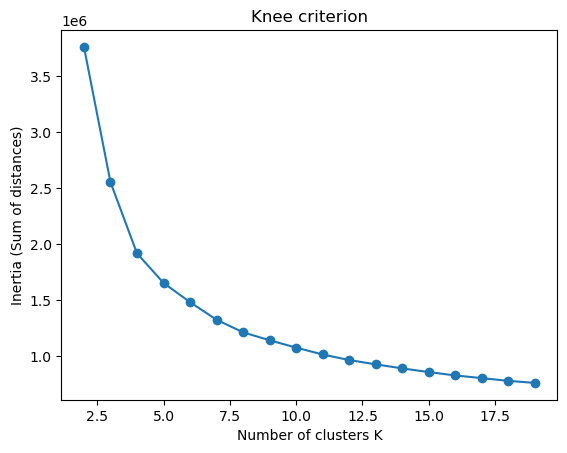

optimal value: k = 5


In [8]:
optimal_k_veg = compute_optimal_k(X_scaled_veg)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply K-Means and display the mean spectrum for each cluster. We also compute the Silhouette score as well as the Calinski-Harabasz Index.

In [9]:
def KMeans_mean_spectra(X_scaled, mask_1D, optimal_k, bands_number, max_samples=10000):
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
    labels = kmeans_final.fit_predict(X_scaled)
    
    n_samples = X_scaled.shape[0]
    
    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels
    
    sil_score = silhouette_score(X_sampled, labels_sampled)
    ch_score  = calinski_harabasz_score(X_scaled, labels)
    
    print(f"Silhouette (sampled) for k = {optimal_k} : {sil_score:.3f}")
    print(f"Calinski-Harabasz for k = {optimal_k} : {ch_score:.2f}")
    
    # Calcul des moyennes par cluster
    mean_spectra = np.zeros((optimal_k, bands_number))
    std_spectra = np.zeros((optimal_k, bands_number))
    
    for k in range(optimal_k):
        cluster_pixels = pixels[mask_1D][labels == k]
        mean_spectra[k] = cluster_pixels.mean(axis=0)
        std_spectra[k]  = cluster_pixels.std(axis=0)
    
    # Option : afficher sous forme de tableau avec pandas
    df_mean_spectra = pd.DataFrame(
        mean_spectra, 
        columns=[f'Bande_{i+1}' for i in range(bands_number)]
    )
    df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]
    
    plt.figure(figsize=(8,5))
    bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610,  2185])
    
    for k in range(optimal_k):
        plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
        plt.fill_between(
            bands,
            mean_spectra[k] - std_spectra[k],
            mean_spectra[k] + std_spectra[k],
            alpha=0.2
        )
    plt.xlabel('Wavelength')
    plt.ylabel('Average value')
    plt.title('Mean spectrum by cluster')
    plt.legend()
    plt.show()
    return labels

Silhouette (sampled) for k = 5 : 0.341
Calinski-Harabasz for k = 5 : 473309.77


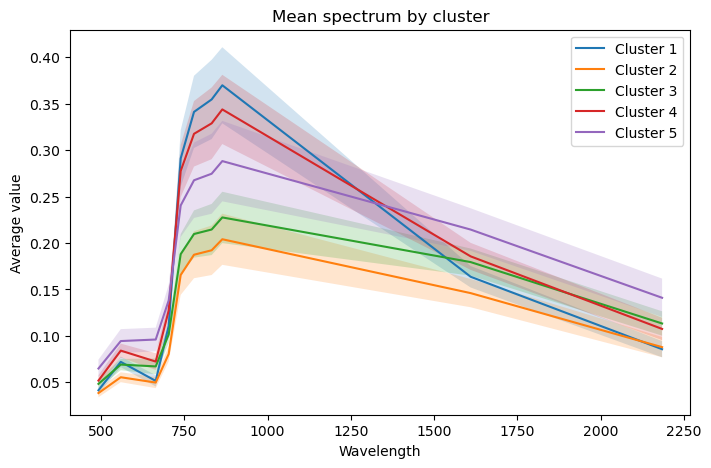

In [10]:
labels_veg = KMeans_mean_spectra(X_scaled_veg, veg_mask_1d, optimal_k_veg, l)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Then, We can display the map with clustered vegetation. Masked pixels are displayed in black.

In [11]:
def display_clusters(mask_2D, labels, optimal_k):
    # --- 7) Construction de la carte finale ---
    cluster_map = np.zeros((m, n), dtype=int)
    cluster_map[mask_2D] = labels + 1  # 0 = fond, clusters à partir de 1
    
    # --- 8) Création de la colormap ---
    cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
    cmap = colors.ListedColormap(cmap_colors)
    
    # --- 9) Affichage ---
    plt.figure(figsize=(10,10))
    plt.imshow(cluster_map, cmap=cmap)
    plt.axis('off')
    #plt.title("Clusters of vegetation")
    plt.show()

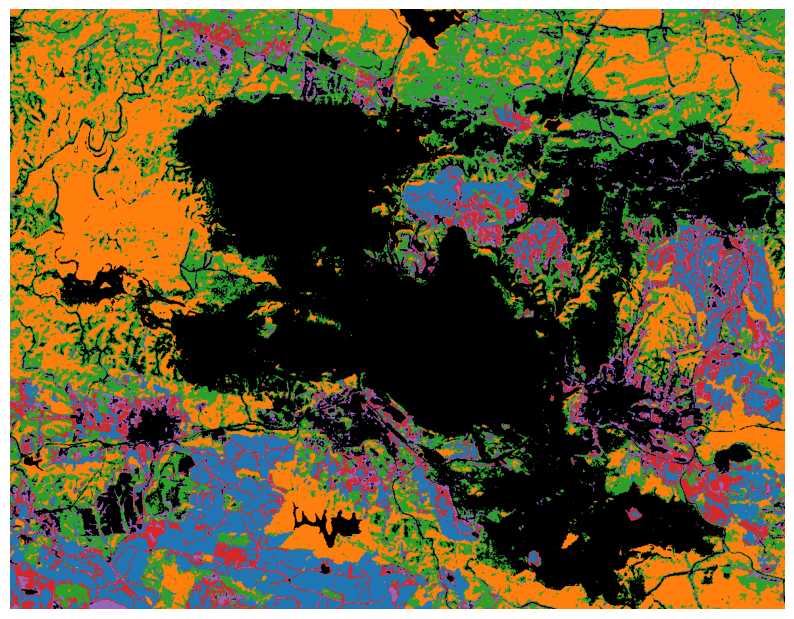

In [12]:
display_clusters(veg_mask_2d, labels_veg, optimal_k_veg)

In [13]:
# Chemins de fichiers (à adapter)
path_ground_truth = 'CS3_HandMadeSAM_lbl.img'

# 1. Lecture de la ground truth
with rio.open(path_ground_truth) as src_gt:
    ground_truth_array = src_gt.read(1)  # Lire la première (et unique) bande

# 2. Création du masque
# 'valid_pixels_mask' est VRAI là où il y a une étiquette de classe valide (> 0)
valid_pixels_mask = ground_truth_array > 0

# ground_truth_labels contient maintenant uniquement les étiquettes valides pour la comparaison
ground_truth_labels = ground_truth_array[valid_pixels_mask]

X_cluster = np.zeros((m,n))
X_cluster[veg_mask_2d] = labels_veg

# 4. Extraction des résultats de clustering pour les pixels valides
# On applique le même masque au résultat du clustering
cluster_labels_for_comparison = X_cluster[valid_pixels_mask]

# Calcul de l'Adjusted Rand Index
ari_score = adjusted_rand_score(
    labels_true=ground_truth_labels, 
    labels_pred=cluster_labels_for_comparison
)

print(f"The partial Adjusted Rand Index (ARI) on vegetation with Direct K-means is : {ari_score:.4f}")

The partial Adjusted Rand Index (ARI) on vegetation with Direct K-means is : 0.4517


<div id="22"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.2 Soil

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the soil.

In [14]:
soil_mask_2d = (soil_only[:, :, 0] != 0)  # prendre la première bande uniquement
soil_mask_1d = soil_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = image.reshape(l, -1).T   
soil_pixels = pixels[soil_mask_1d]     

scaler = StandardScaler()
X_scaled_soil = scaler.fit_transform(soil_pixels)

img_scaled_soil_complete = pixels.copy()
img_scaled_soil_complete[soil_mask_1d] = X_scaled_soil
img_scaled_soil_complete[~soil_mask_1d] = np.mean(X_scaled_soil)


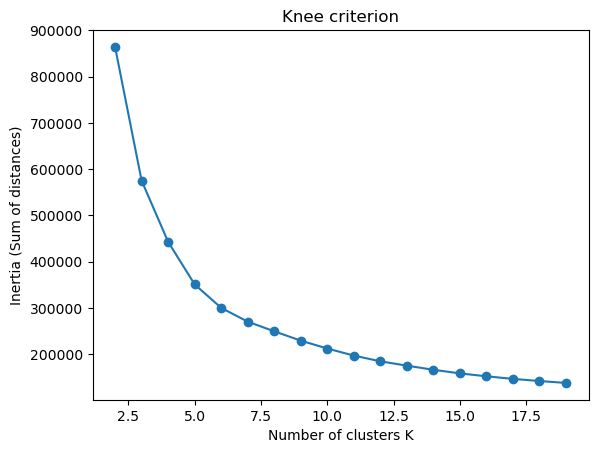

optimal value: k = 6


In [15]:
optimal_k_soil = compute_optimal_k(X_scaled_soil)

<div style="background-color: #f6bcb2; border-left: 5px solid #ff0000; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: 2d3436;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We decide to not use the optimal k for soil due to external knowledge, using k = 30 instead. 

In [16]:
optimal_k_soil = 30

Silhouette (sampled) for k = 30 : 0.217
Calinski-Harabasz for k = 30 : 88761.90


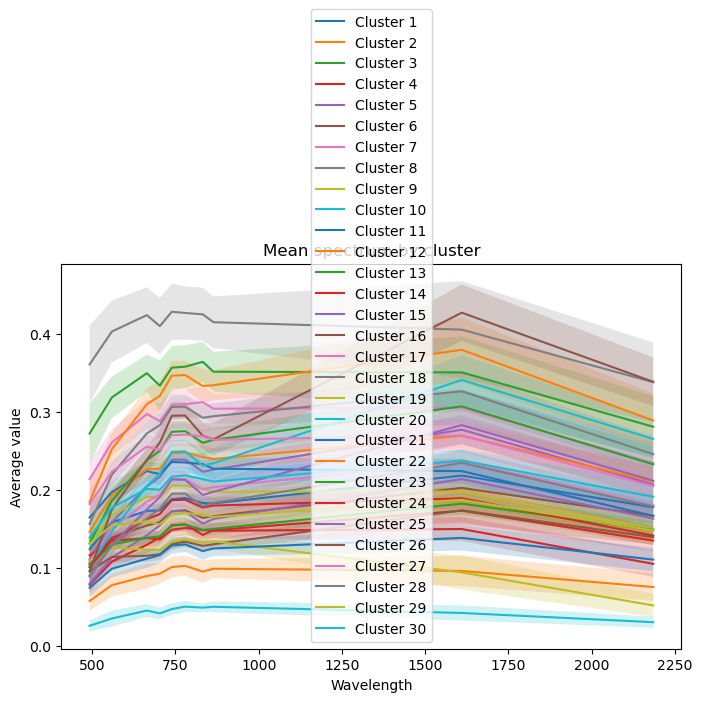

In [17]:
labels_soil = KMeans_mean_spectra(X_scaled_soil, soil_mask_1d, optimal_k_soil, l)

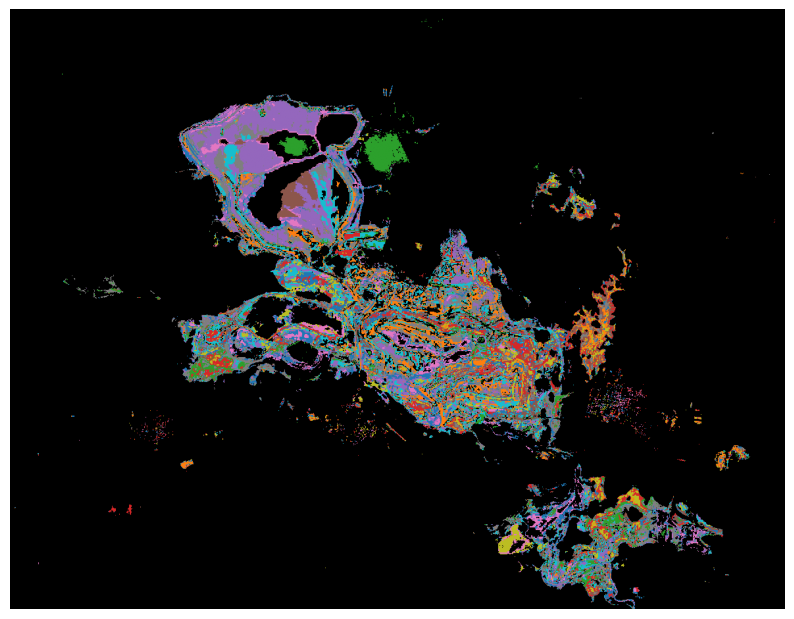

In [18]:
display_clusters(soil_mask_2d, labels_soil, optimal_k_soil)

<div id="23"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.3 Other

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the rest.

In [19]:
other_mask_2d = (soil_only[:, :, 0] == 0) & (vegetation_only[:,:,0]== 0)  # prendre la première bande uniquement
other_mask_1d = other_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
other_pixels = pixels[other_mask_1d]             

scaler = StandardScaler()
X_scaled_other = scaler.fit_transform(other_pixels)

img_scaled_other_complete = pixels.copy()
img_scaled_other_complete[other_mask_1d] = X_scaled_other
img_scaled_other_complete[~other_mask_1d] = np.mean(X_scaled_other)

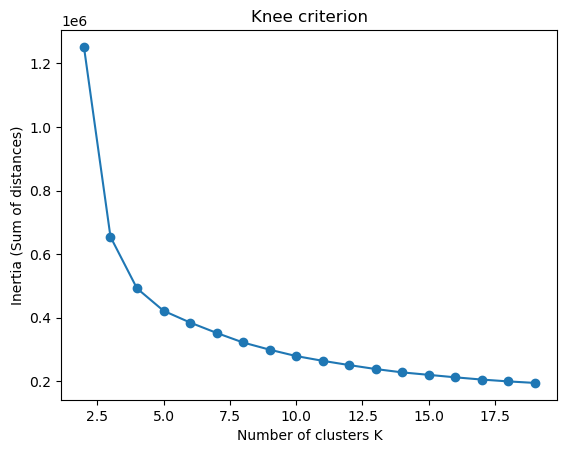

optimal value: k = 5


In [20]:
optimal_k_other = compute_optimal_k(X_scaled_other)

Silhouette (sampled) for k = 5 : 0.310
Calinski-Harabasz for k = 5 : 266775.73


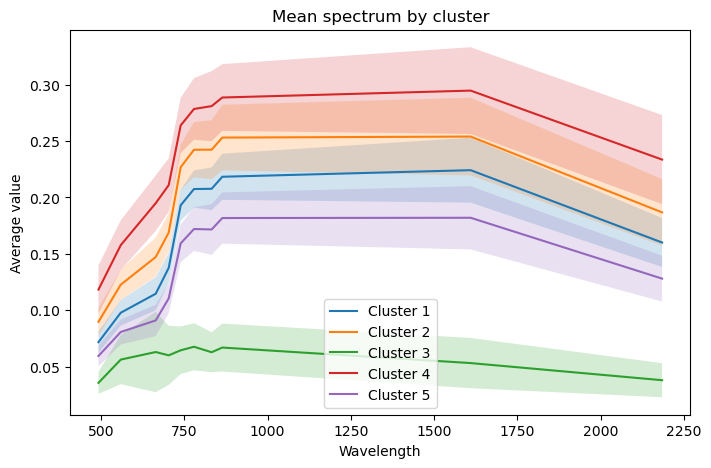

In [21]:
labels_other = KMeans_mean_spectra(X_scaled_other, other_mask_1d, optimal_k_other, l)

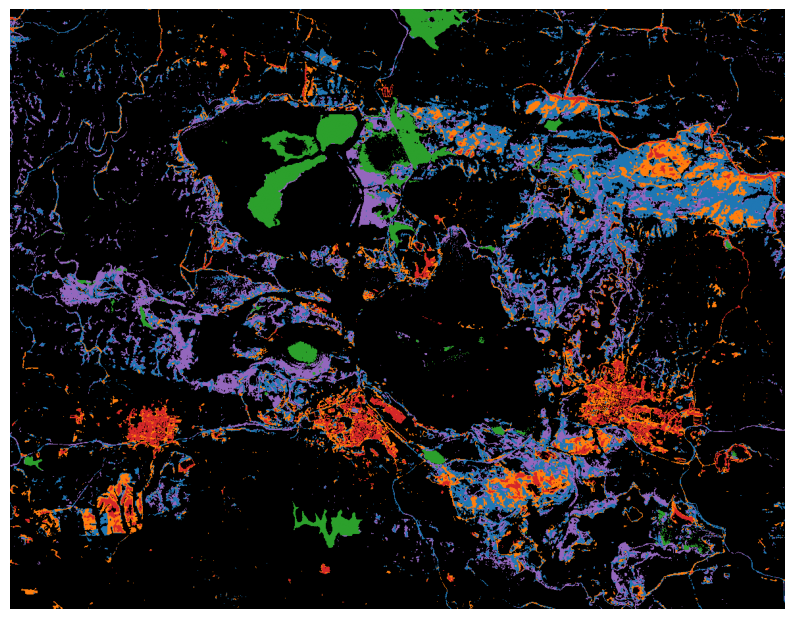

In [22]:
display_clusters(other_mask_2d, labels_other, optimal_k_other)

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    3. Pixel-by-Pixel AutoEncoder with K-Means on latent-space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We first try an AutoEncoder which takes separately each pixel and gives a latent representation. We then apply the K-means algorithm on these representations with the values of "optimal K" obtained precedently.

In [23]:
class PbPAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim, dropout_rate=0.2):
        super().__init__()

        # Hyperparamètres
        self.latent_dim = latent_dim
        self.dropout_rate = dropout_rate

        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate), # Régularisation
            
            # 2. Deuxième couche : Compression intermédiaire
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate), # Régularisation
            
            # 3. Troisième couche (Couche latente)
            nn.Linear(256, latent_dim)
        )

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            # 1. Premiére couche : Décompression intermédiaire
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            
            # 2. Deuxième couche : Décompression avancée
            nn.Linear(256, 512),
            nn.ReLU(),
            
            # 3. Dernière couche : Reconstruction de l'entrée
            nn.Linear(512, in_dim),
            nn.Sigmoid() # Pour s'assurer que les pixels sont entre 0 et 1
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [24]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x, in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [25]:
def train_PbP_autoencoder(LATENT_DIM, EPOCHS, X_scaled, n_clusters, max_samples=10000):

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    dataset = TensorDataset(X_tensor.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = PbPAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        for x, in loader:
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(loader):.6f}")

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    kmeans = KMeans(n_clusters, n_init=5, random_state=0)
    labels_1d = kmeans.fit_predict(latent_vectors)

    n_samples = X_scaled.shape[0]

    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels_1d[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels_1d

    sil_score = silhouette_score(X_sampled, labels_sampled)
    ch_score  = calinski_harabasz_score(X_sampled, labels_sampled)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")
    print(f"Calinski-Harabasz pour k = {n_clusters} : {ch_score:.2f}")

    return labels_1d

In [26]:
def get_n_colors(n):
    base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.
    colors = base(np.linspace(0, 1, n))
    return colors.ListedColormap(colors)

<div id="31"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.1 Vegetation (and partial ARI)

In [27]:
labels_1d_veg = train_PbP_autoencoder(4, 5, X_scaled_veg, optimal_k_veg)

Epoch 1/5   Loss = 0.530139
Epoch 2/5   Loss = 0.525374
Epoch 3/5   Loss = 0.524998
Epoch 4/5   Loss = 0.524713
Epoch 5/5   Loss = 0.524604
Silhouette (échantillon) pour k = 5 : 0.264
Calinski-Harabasz pour k = 5 : 6264.05


In [28]:
X_cluster = np.zeros((m,n))
X_cluster[veg_mask_2d] = labels_veg

# 4. Extraction des résultats de clustering pour les pixels valides
# On applique le même masque au résultat du clustering
cluster_labels_for_comparison = X_cluster[valid_pixels_mask]

# Calcul de l'Adjusted Rand Index
ari_score = adjusted_rand_score(
    labels_true=ground_truth_labels, 
    labels_pred=cluster_labels_for_comparison
)

print(f"The partial Adjusted Rand Index (ARI) on vegetation with PbP Autoencoder + K-means on latent space is : {ari_score:.4f}")

The partial Adjusted Rand Index (ARI) on vegetation with PbP Autoencoder + K-means on latent space is : 0.4517


<div id="32"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.2 Soil

In [29]:
train_PbP_autoencoder(4, 5, X_scaled_soil, optimal_k_soil)

Epoch 1/5   Loss = 0.593579
Epoch 2/5   Loss = 0.583150
Epoch 3/5   Loss = 0.582607
Epoch 4/5   Loss = 0.582195
Epoch 5/5   Loss = 0.582164
Silhouette (échantillon) pour k = 30 : 0.157
Calinski-Harabasz pour k = 30 : 4121.10


array([10, 10, 10, ..., 20, 29, 16], shape=(171907,), dtype=int32)

<div id="33"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.3 Other

In [30]:
train_PbP_autoencoder(4, 5, X_scaled_other, optimal_k_other)

Epoch 1/5   Loss = 0.633341
Epoch 2/5   Loss = 0.624311
Epoch 3/5   Loss = 0.623819
Epoch 4/5   Loss = 0.623584
Epoch 5/5   Loss = 0.623389
Silhouette (échantillon) pour k = 5 : 0.297
Calinski-Harabasz pour k = 5 : 8627.15


array([1, 2, 1, ..., 1, 1, 1], shape=(234214,), dtype=int32)

<div id="40"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    4. 2D Convolutional AutoEncoder with K-Means on latent space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
As our non-Convolutional AE provides poor results, we will now focus on Convolutional Autoencoders. We apply the K-means algorithm on the latent representation of patches (16*16 pixels for instance). To "propagate" the classification information, there are different options. 

In [31]:
LATENT_DIM = 64
EPOCHS = 20
PATCH_SIZE = 32
STRIDE = 8
BATCH_SIZE = 128

In [32]:
print(img_scaled_veg_complete.shape)
print(m, n)

(1074336, 10)
912 1178


In [33]:
# --- Residual Block ---
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out


class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=LATENT_DIM):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder, self).__init__()

        self.latent_dim = latent_dim

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1),  # H/2
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Dropout2d(0.2),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),           # H/4
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            ResidualBlock(64),  # Residual pour enrichir la représentation

            nn.Conv2d(64, 128, 3, stride=2, padding=1),          # H/8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            ResidualBlock(128),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),         # H/16
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.Dropout2d(0.2)

        )
        
        # Global Average Pooling → invariant à taille patch
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc_enc = nn.Linear(256, self.latent_dim)  # on initialisera dynamiquement au premier forward
        self.fc_dec = nn.Linear(self.latent_dim, 256)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(

            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            ResidualBlock(128),

            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # H*2
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            ResidualBlock(64),

            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding = 1),   # H*2
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, in_channels, 3,stride= 2, padding=1, output_padding = 1),    # H*2
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        z = self.encoder_conv(x)
        z = self.global_pool(z)
        z_flat = z.view(z.size(0), -1)        # Flatten
        z_latent = self.fc_enc(z_flat)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(z_dec.size(0), 256, 1, 1)
        x_recon = self.decoder_conv(z_dec)
        
 # Interpolation pour correspondre exactement à la taille du patch d'entrée
        x_recon = F.interpolate(x_recon, size=(x.size(2), x.size(3)), mode='bilinear', align_corners=False)

        return x_recon, z_latent
    
    def encode(self, x):
        z = self.encoder_conv(x)
        z = self.global_pool(z)
        z_flat = z.view(z.size(0), -1)
        z_latent = self.fc_enc(z_flat)
        return z_latent

In [34]:
def fill_invalid_pixels_with_mean(x_batch, mask_batch):
    """
    x_batch: (B, C, H, W)
    mask_batch: (B, H, W) avec 0 / 1
    """
    B, C, H, W = x_batch.shape

    mask = mask_batch.unsqueeze(1)  # (B,1,H,W)

    # nombre de pixels valides par patch
    valid_count = mask.sum(dim=(2, 3), keepdim=True).clamp(min=1)

    # moyenne par canal et par patch
    mean_vals = (x_batch * mask).sum(dim=(2, 3), keepdim=True) / valid_count

    # remplacement
    x_filled = x_batch * mask + mean_vals * (1 - mask)

    return x_filled

In [35]:
def generate_valid_patches(img_tensor, mask_tensor, patch_size, stride, batch_size=128, min_valid_ratio=0.8):
    """
    Génère des batches d'apprentissage où chaque patch a au moins min_valid_ratio de pixels valides
    """
    _, H, W = img_tensor.shape
    # 1️⃣ Lister toutes les positions possibles
    positions = [(i,j) for i in range(H - patch_size + 1) for j in range(W - patch_size + 1)]
    random.shuffle(positions)
    patches = []

    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patch = img_tensor[:, i:i+patch_size, j:j+patch_size]
            mask_patch = mask_tensor[i:i+patch_size, j:j+patch_size]

            valid_ratio = mask_patch.sum() / (patch_size * patch_size)
            if valid_ratio < min_valid_ratio:
                continue  # rejet du patch

            # Remplacement des pixels invalides par la moyenne locale
            mask_patch_exp = mask_patch.unsqueeze(0)  # (1,H,W)
            valid_count = mask_patch_exp.sum(dim=(1,2), keepdim=True).clamp(min=1)
            mean_vals = (patch * mask_patch_exp).sum(dim=(1,2), keepdim=True) / valid_count
            patch_filled = patch * mask_patch_exp + mean_vals * (1 - mask_patch_exp)

            patches.append(patch_filled.unsqueeze(0))

            if len(patches) == batch_size:
                yield torch.cat(patches, dim=0)
                patches.clear()

    if patches:
        yield torch.cat(patches, dim=0)

In [36]:
def generate_patches_centered(img_tensor, mask_tensor, patch_size, sampled_positions, batch_size=128):
    """
    Génère des patches centrés sur les pixels de référence (i,j)
    """
    patches = []
    half = patch_size // 2
    C, H, W = img_tensor.shape

    for i,j in sampled_positions:
        i_start = i - half
        i_end   = i + half
        j_start = j - half
        j_end   = j + half

        # Clip pour rester dans l'image
        i_start_clip = max(0, i_start)
        i_end_clip   = min(H, i_end)
        j_start_clip = max(0, j_start)
        j_end_clip   = min(W, j_end)

        patch = img_tensor[:, i_start_clip:i_end_clip, j_start_clip:j_end_clip].unsqueeze(0)

        # Padding si nécessaire
        pad_top    = i_start_clip - i_start
        pad_bottom = i_end - i_end_clip
        pad_left   = j_start_clip - j_start
        pad_right  = j_end - j_end_clip

        patch = F.pad(patch, (pad_left, pad_right, pad_top, pad_bottom))
        patches.append(patch)

        if len(patches) == batch_size:
            yield torch.cat(patches, dim=0)
            patches.clear()

    if patches:
        yield torch.cat(patches, dim=0)


def train_Conv2D_autoencoder(EPOCHS, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_complete, mask_2d, MAX_BATCHES_PER_EPOCH, MAX_LATENTS, VEG_THRESHOLD=0.8):

    # --- Configuration ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Utilization du device : {DEVICE}")

    # --- Initialisation du Modèle ---
    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    img_tensor = torch.Tensor(img_scaled_complete.T.reshape(l,m,n))
    mask_tensor = torch.Tensor(mask_2d)
    
    """
    mask_tensor = torch.tensor(mask_2d, dtype=torch.float32)
    all_patch_tensor, all_positions = extract_valid_patches_with_mask(
    torch.Tensor(img_scaled_complete.T.reshape(l,m,n)), 
    torch.ones_like(mask_tensor),  # masque plein pour tous les pixels
    PATCH_SIZE, STRIDE)
    dataset_all = TensorDataset(all_patch_tensor)
    loader_test = DataLoader(dataset_all, batch_size=BATCH_SIZE, shuffle=False)
    """

    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        accepted_batches = 0

        for batch in generate_valid_patches(
            img_tensor, mask_tensor,
            PATCH_SIZE, STRIDE, BATCH_SIZE, VEG_THRESHOLD
        ):
            
            batch = batch.to(DEVICE)

            optimizer.zero_grad()
            out, _ = model(batch)
            loss = criterion(out, batch)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            accepted_batches += 1

            if accepted_batches >= MAX_BATCHES_PER_EPOCH:
                break

        print(f"Epoch {ep+1}/{EPOCHS} | Batches: {accepted_batches} | Loss: {loss_sum/max(1, accepted_batches):.6f}")

        torch.cuda.empty_cache()

    # --------------------------
    # PHASE 2 : EXTRACTION DES LATENTS
    # --------------------------
    model.eval()
    model.cpu()

    _, H, W = img_tensor.shape


    # 1️⃣ Lister tous les pixels valides pour le patch top-left
    valid_positions = [
        (i,j)
        for i in range(H - PATCH_SIZE + 1)
        for j in range(W - PATCH_SIZE + 1)
        if mask_tensor[i,j] == 1
    ]

    # 2️⃣ Échantillon aléatoire
    if len(valid_positions) > MAX_LATENTS:
        sampled_positions = random.sample(valid_positions, MAX_LATENTS)
    else:
        sampled_positions = valid_positions

    # 2️⃣ Construire patches centrés batch par batch
    all_latents = []
    for patch_batch in generate_patches_centered(img_tensor, mask_tensor, PATCH_SIZE, sampled_positions, batch_size=BATCH_SIZE):
        with torch.no_grad():
            z = model.encode(patch_batch)  # (B, latent_dim)
        all_latents.append(z.cpu().numpy())
    latents = np.concatenate(all_latents, axis=0)

    return latents, sampled_positions

<div id="41"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.1 Vegetation (and ARI)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
A simple option is to assume the cluster assigned to the patch is in reality the cluster assigned to the pixel at the center of this patch.

In [37]:
class PatchDataset(Dataset):
    def __init__(self, cube, patch_size):
        """
        cube        : tensor [bands, H, W]
        patch_size  : int
        """
        self.cube = cube
        self.patch = patch_size
        self.pad = patch_size // 2

        # padding pour ne pas perdre les bords
        self.cube_pad = F.pad(cube, (self.pad, self.pad, self.pad, self.pad))

        self.H, self.W = cube.shape[1], cube.shape[2]

    def __len__(self):
        return self.H * self.W

    def __getitem__(self, idx):
        h = idx // self.W
        w = idx % self.W

        patch = self.cube_pad[:, 
                              h : h + 2*self.pad + 1,
                              w : w + 2*self.pad + 1]

        return patch   # shape = [bands, patch, patch]

In [38]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [39]:
def KM_Silhouette(latent_vectors, n_clusters):
    kmeans = KMeans(n_clusters, n_init=5, random_state=0)
    scaler = StandardScaler()
    latent_norms = scaler.fit_transform(latent_vectors)
    labels = kmeans.fit_predict(latent_norms)
    sample = random.sample(range(latent_vectors.shape[0]), 10000)
    latent_vectors_sampled = latent_vectors[sample, :]
    labels_sampled = labels[sample]
    
    sil_score = silhouette_score(latent_vectors_sampled, labels_sampled)
    print(f"Silhouette (on a subset) for k = {n_clusters} : {sil_score:.3f}")
    ch_score  = calinski_harabasz_score(latent_vectors_sampled, labels_sampled)
    print(f"Calinski-Harabasz for k = {n_clusters} : {ch_score:.2f}")

    return labels

In [40]:
latent_vectors_veg, positions = train_Conv2D_autoencoder(
    EPOCHS,  
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_veg_complete, veg_mask_2d, MAX_BATCHES_PER_EPOCH=50, MAX_LATENTS = 100000
)

#EPOCHS, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_complete, mask_2d, MAX_BATCHES_PER_EPOCH, MAX_LATENTS, VEG_THRESHOLD=0.8


Utilization du device : cuda
Epoch 1/20 | Batches: 50 | Loss: 1.027421
Epoch 2/20 | Batches: 50 | Loss: 0.876332
Epoch 3/20 | Batches: 50 | Loss: 0.847923
Epoch 4/20 | Batches: 50 | Loss: 0.845710
Epoch 5/20 | Batches: 50 | Loss: 0.840721
Epoch 6/20 | Batches: 50 | Loss: 0.836146
Epoch 7/20 | Batches: 50 | Loss: 0.827899
Epoch 8/20 | Batches: 50 | Loss: 0.822635
Epoch 9/20 | Batches: 50 | Loss: 0.822090
Epoch 10/20 | Batches: 50 | Loss: 0.821717
Epoch 11/20 | Batches: 50 | Loss: 0.819153
Epoch 12/20 | Batches: 50 | Loss: 0.816088
Epoch 13/20 | Batches: 50 | Loss: 0.818334
Epoch 14/20 | Batches: 50 | Loss: 0.807556
Epoch 15/20 | Batches: 50 | Loss: 0.806238
Epoch 16/20 | Batches: 50 | Loss: 0.805012
Epoch 17/20 | Batches: 50 | Loss: 0.802693
Epoch 18/20 | Batches: 50 | Loss: 0.802547
Epoch 19/20 | Batches: 50 | Loss: 0.795305
Epoch 20/20 | Batches: 50 | Loss: 0.792380


In [41]:
labels_veg = KM_Silhouette(latent_vectors_veg, optimal_k_veg)

Silhouette (on a subset) for k = 5 : 0.481
Calinski-Harabasz for k = 5 : 17312.48


In [42]:
from collections import Counter
cluster_counts = Counter(labels_veg)
print(cluster_counts)

Counter({np.int32(0): 48963, np.int32(2): 17932, np.int32(1): 16279, np.int32(4): 8842, np.int32(3): 7984})


In [43]:
# Nombre de patches clustérisés (taille N)
N_patches = len(labels_veg)
# Décalage pour trouver le pixel central du patch
center_offset = PATCH_SIZE // 2

# --- 2. Création de la Vraie Étiquette ALIGNÉE (y_true_reordered) ---

# Créer un tableau de taille N_patches, initialisé à 0
y_true_reordered = np.zeros(N_patches, dtype=np.int32) 

# Parcourir chaque patch dans l'ordre de 'positions' (et donc de 'labels_veg')
for i, (r_start, c_start) in enumerate(positions):
    r_center = r_start + center_offset
    c_center = c_start + center_offset
    
    # Récupérer l'étiquette GT du pixel central du patch
    # Les valeurs de 0 (non étiqueté) ou > 0 (classe) sont stockées
    if r_center < m and c_center < n:
        y_true_reordered[i] = ground_truth_array[r_center, c_center]

# --- 3. Filtrage Simultané pour l'ARI ---

# 3a. Créer le masque de filtrage : True là où l'étiquette GT est connue (GT > 0)
mask_labeled = (y_true_reordered > 0) 

# 3b. Application du masque : y_true_final et y_pred_final ont la même taille M
labels_true_final = y_true_reordered[mask_labeled] # Vraies étiquettes filtrées
labels_pred_final = labels_veg[mask_labeled]      # Prédictions filtrées (alignées)

cluster_counts_true = Counter(labels_true_final)
print(cluster_counts_true)
cluster_counts_pred = Counter(labels_pred_final)
print(cluster_counts_pred)

# --- 4. Calcul de l'Adjusted Rand Index CORRIGÉ ---

if len(labels_true_final) > 0:
    ari_score_corrected = adjusted_rand_score(
        labels_true=labels_true_final, 
        labels_pred=labels_pred_final
    )
    print("-" * 70)
    print(f"✅ Adjusted Rand Index (ARI) CORRIGÉ sur {len(labels_true_final)} échantillons : {ari_score_corrected:.4f}")
    print("-" * 70)
else:
    print("❌ ERREUR D'ÉVALUATION : Aucun patch extrait ne correspond à un pixel étiqueté dans la vérité terrain.")

Counter({np.int32(4): 2821, np.int32(1): 2192, np.int32(3): 1314, np.int32(2): 582, np.int32(5): 90})
Counter({np.int32(0): 2923, np.int32(1): 2260, np.int32(2): 706, np.int32(3): 672, np.int32(4): 438})
----------------------------------------------------------------------
✅ Adjusted Rand Index (ARI) CORRIGÉ sur 6999 échantillons : 0.2355
----------------------------------------------------------------------


In [44]:
ground_truth_labels_image = np.full((m, n), -1)
ground_truth_labels_image[valid_pixels_mask] = ground_truth_labels

X_cluster = np.full((m, n), -1)
for (i, j), label in zip(positions, labels_veg):
    end_i = min(i + PATCH_SIZE, m)
    end_j = min(j + PATCH_SIZE, n)
    X_cluster[i:end_i, j:end_j] = label
comparison_mask = (ground_truth_labels_image != -1) & (X_cluster != -1)

if comparison_mask.sum() > 0:
    y_true_final = ground_truth_labels_image[comparison_mask]
    y_pred_final = X_cluster[comparison_mask]

    ari_score = adjusted_rand_score(y_true_final, y_pred_final)
    print(f"Partial Adjusted Rand Index (ARI): {ari_score:.4f}")
    print(f"Calculé sur {comparison_mask.sum()} pixels communs.")
else:
    print("Erreur : Aucun recouvrement entre les patchs prédits et la vérité terrain.")

Partial Adjusted Rand Index (ARI): 0.2389
Calculé sur 51265 pixels communs.


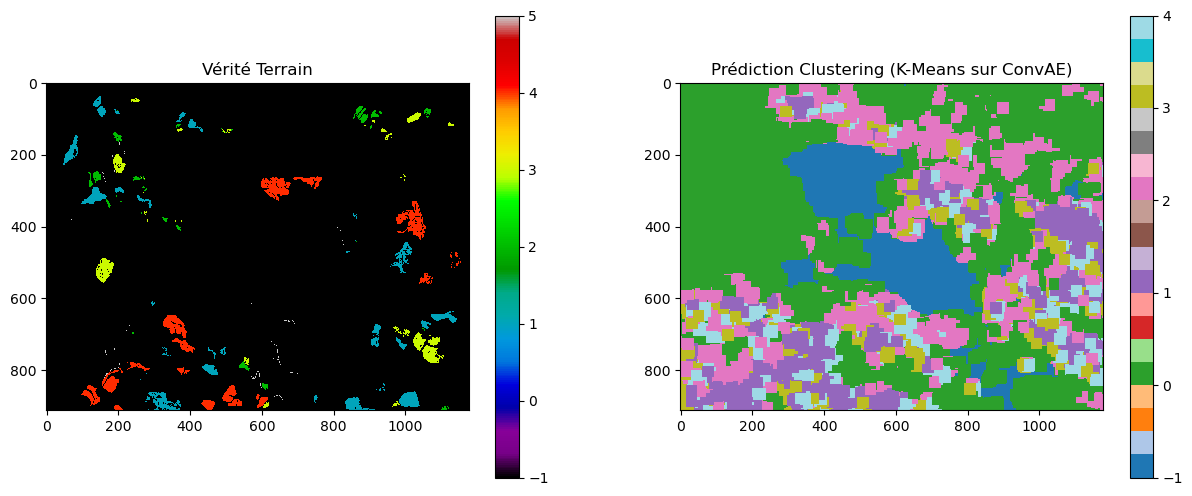

In [45]:
plt.figure(figsize=(15, 6))

# 1. Vérité Terrain
plt.subplot(1, 2, 1)
plt.imshow(ground_truth_labels_image, cmap='nipy_spectral', interpolation='nearest')
plt.title("Vérité Terrain")
plt.colorbar()

display_cluster = X_cluster.copy()

plt.subplot(1, 2, 2)
plt.imshow(display_cluster, cmap='tab20', interpolation='nearest')
plt.title("Prédiction Clustering (K-Means sur ConvAE)")
plt.colorbar()

plt.show()

<div id="42"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.2 Soil

In [46]:
latent_vectors_soil, positions = train_Conv2D_autoencoder(
    EPOCHS,  
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_soil_complete, soil_mask_2d, MAX_BATCHES_PER_EPOCH=50, MAX_LATENTS = 100000
)

Utilization du device : cuda
Epoch 1/20 | Batches: 13 | Loss: 1.027580
Epoch 2/20 | Batches: 13 | Loss: 0.942377
Epoch 3/20 | Batches: 13 | Loss: 0.887118
Epoch 4/20 | Batches: 13 | Loss: 0.836147
Epoch 5/20 | Batches: 13 | Loss: 0.810799
Epoch 6/20 | Batches: 13 | Loss: 0.787670
Epoch 7/20 | Batches: 13 | Loss: 0.774250
Epoch 8/20 | Batches: 13 | Loss: 0.761340
Epoch 9/20 | Batches: 13 | Loss: 0.755567
Epoch 10/20 | Batches: 13 | Loss: 0.741304
Epoch 11/20 | Batches: 13 | Loss: 0.734825
Epoch 12/20 | Batches: 13 | Loss: 0.722944
Epoch 13/20 | Batches: 13 | Loss: 0.720715
Epoch 14/20 | Batches: 13 | Loss: 0.718209
Epoch 15/20 | Batches: 13 | Loss: 0.713587
Epoch 16/20 | Batches: 13 | Loss: 0.698387
Epoch 17/20 | Batches: 13 | Loss: 0.693287
Epoch 18/20 | Batches: 13 | Loss: 0.685167
Epoch 19/20 | Batches: 13 | Loss: 0.682410
Epoch 20/20 | Batches: 13 | Loss: 0.678015


In [47]:
labels_soil = KM_Silhouette(latent_vectors_soil, optimal_k_soil)

Silhouette (on a subset) for k = 30 : 0.279
Calinski-Harabasz for k = 30 : 6969.14


<div id="43"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.3 Other

In [48]:
latent_vectors_other, positions = train_Conv2D_autoencoder(
    EPOCHS,  
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_other_complete, other_mask_2d, MAX_BATCHES_PER_EPOCH=50, MAX_LATENTS = 100000
)

Utilization du device : cuda
Epoch 1/20 | Batches: 6 | Loss: 1.119429
Epoch 2/20 | Batches: 6 | Loss: 1.060795
Epoch 3/20 | Batches: 6 | Loss: 1.009566
Epoch 4/20 | Batches: 6 | Loss: 0.966382
Epoch 5/20 | Batches: 6 | Loss: 0.929074
Epoch 6/20 | Batches: 6 | Loss: 0.901053
Epoch 7/20 | Batches: 6 | Loss: 0.878109
Epoch 8/20 | Batches: 6 | Loss: 0.862980
Epoch 9/20 | Batches: 6 | Loss: 0.849010
Epoch 10/20 | Batches: 6 | Loss: 0.838517
Epoch 11/20 | Batches: 6 | Loss: 0.830543
Epoch 12/20 | Batches: 6 | Loss: 0.822329
Epoch 13/20 | Batches: 6 | Loss: 0.817546
Epoch 14/20 | Batches: 6 | Loss: 0.808341
Epoch 15/20 | Batches: 6 | Loss: 0.803012
Epoch 16/20 | Batches: 6 | Loss: 0.798921
Epoch 17/20 | Batches: 6 | Loss: 0.793492
Epoch 18/20 | Batches: 6 | Loss: 0.790785
Epoch 19/20 | Batches: 6 | Loss: 0.787062
Epoch 20/20 | Batches: 6 | Loss: 0.785184


In [49]:
labels_other = KM_Silhouette(latent_vectors_other, optimal_k_other)

Silhouette (on a subset) for k = 5 : 0.348
Calinski-Harabasz for k = 5 : 8362.03


<div id="44"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.4 Nombre de clusters pour la végétation avec CDH

In [50]:
N = 20000
idx = np.random.choice(len(X_scaled_veg), N, replace=False)
X_sample = X_scaled_veg[idx]
X_sample_original = veg_pixels[idx]
#print(X_sample.shape)
#print(X_sample_original.shape)

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

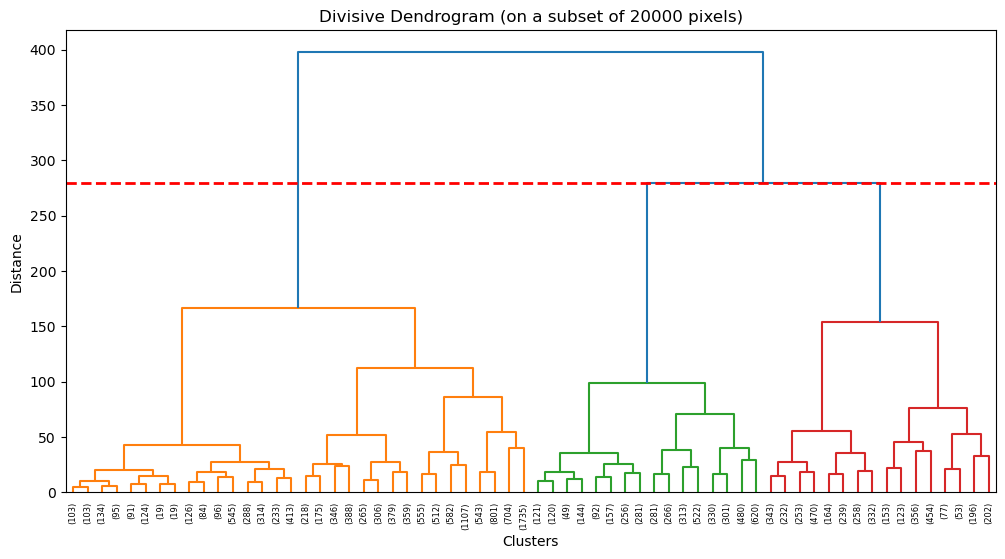

In [51]:
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Divisive Dendrogram (on a subset of 20000 pixels)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

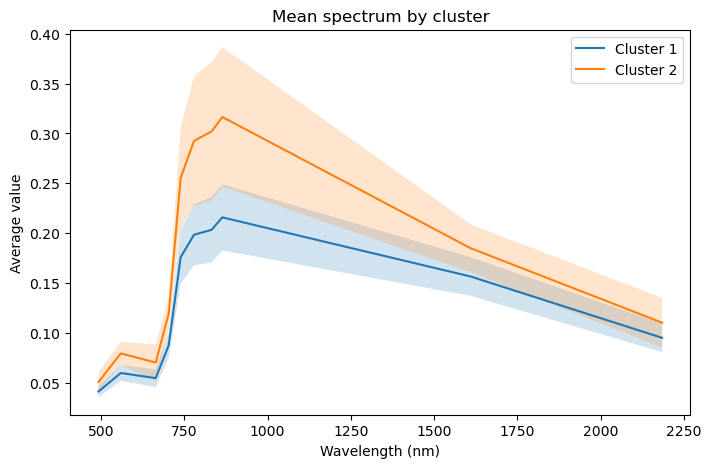

In [52]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610, 2185])

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep two clusters. The mean spectrum shows that cluster one keeps a higher reflectance on all wavelengths, thus corresponding to sane, dense vegetation (forests). Cluster two, with lower reflectance, corresponds to more sparse vegetation (shrubs).

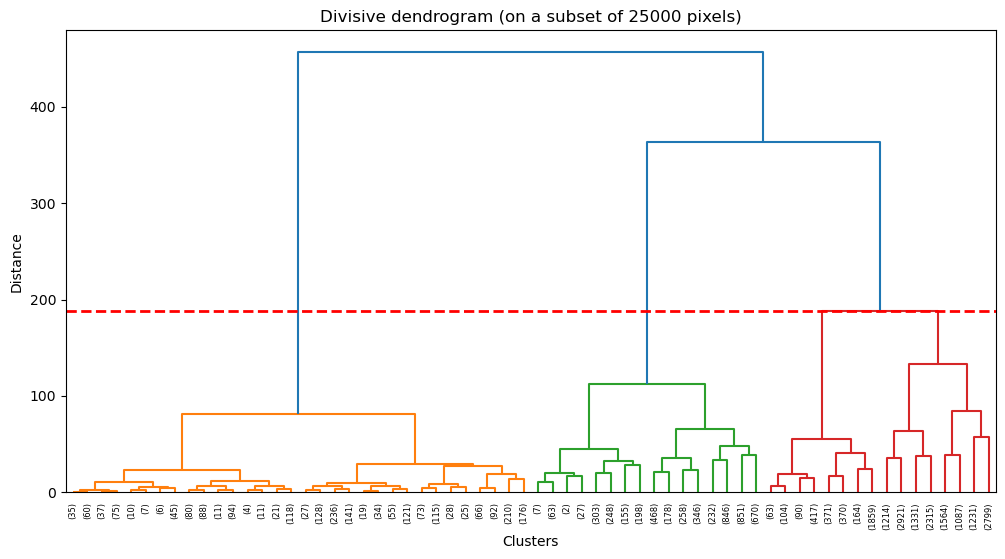

In [53]:
N = 25000
idx_selected = np.random.choice(len(X_scaled_other), N, replace=False)
X_sample = X_scaled_other[idx_selected]
X_sample_original = other_pixels[idx_selected]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Divisive dendrogram (on a subset of 25000 pixels)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()


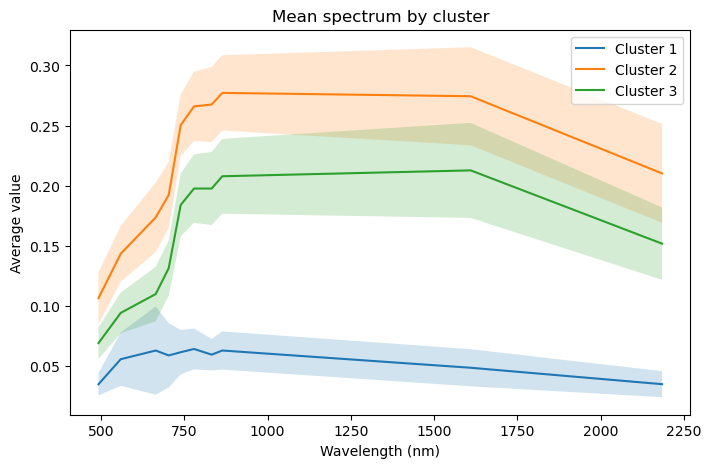

In [54]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610, 2185])

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep three clusters. The mean spectrum shows that cluster one keeps a very low reflectance on all wavelengths : this is characteristic of water areas. Cluster two shows high values of reflectance on SWIR wavelengths, which could correspond to urban areas (building materials). Cluster three has a similar shape compared to cluster two but with higher reflectance values : it may also correspond to urban areas, but roads/asphalt spaces rather than buildings.

In [55]:
def display_clusters_subset(mask_2D, idx, labels, optimal_k):
    # --- 7) Construction de la carte finale ---
    cluster_map = np.zeros((m, n), dtype=int)

    indices = np.where(mask_2D.ravel())[0] # Indices 1D dans le tableau aplati
    indices_to_color = indices[idx]
    cluster_map.ravel()[indices_to_color] = labels + 1
    
    # --- 8) Création de la colormap ---
    cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
    cmap = colors.ListedColormap(cmap_colors)
    
    # --- 9) Affichage ---
    plt.figure(figsize=(10,10))
    plt.imshow(cluster_map, cmap=cmap)
    plt.axis('off')
    #plt.title("Clusters of vegetation")
    plt.show()

In [56]:
#display_clusters_subset(other_mask_2d, idx_selected, labels, np.unique(labels).shape[0])

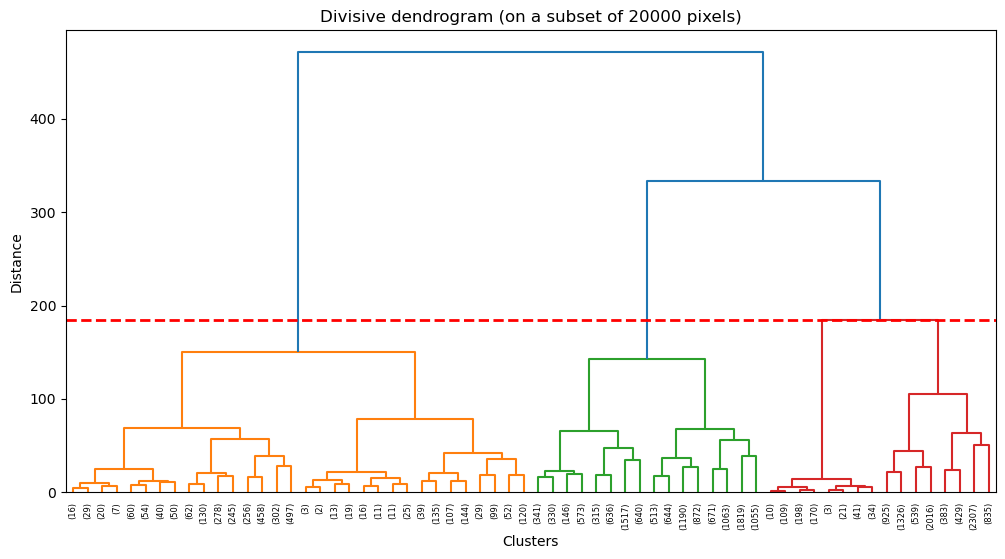

In [57]:
N = 25000
idx = np.random.choice(len(X_scaled_soil), N, replace=False)
X_sample = X_scaled_soil[idx]
X_sample_original = soil_pixels[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Divisive dendrogram (on a subset of 20000 pixels)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

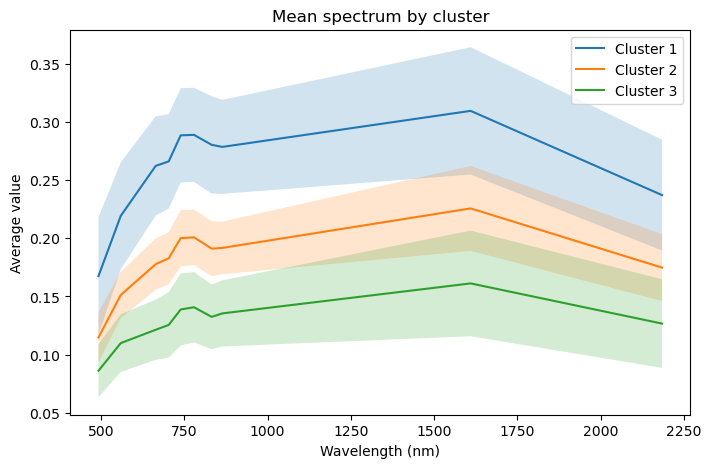

In [58]:
# img : (H, W, B)
# labels : (H, W) avec 0 ou 1

# Calcul des spectres moyens et écart-types
mean_spectra = []
std_spectra = []
valid_clusters = []

for k in np.unique(labels):
    pixels_k = X_sample_original[labels == k]  # extraire les pixels de la classe k
    if pixels_k.size == 0:
        continue  # ignorer les classes vides
    mean_spectra.append(pixels_k.mean(axis=0))
    std_spectra.append(pixels_k.std(axis=0))
    valid_clusters.append(k)

mean_spectra = np.array(mean_spectra)
std_spectra = np.array(std_spectra)
bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610, 2185])

# Affichage
plt.figure(figsize=(8,5))
for idx, k in enumerate(valid_clusters):
    plt.plot(bands, mean_spectra[idx], label=f'Cluster {k}')
    plt.fill_between(
        bands,
        mean_spectra[idx] - std_spectra[idx],
        mean_spectra[idx] + std_spectra[idx],
        alpha=0.2
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Average value')
plt.title('Mean spectrum by cluster')
plt.legend()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
Divisive Hierarchical Clustering suggests to only keep two clusters. The mean spectrum shows that both clusters have similar shapes, but that cluster one has lower reflectance, which could be due to the presence of water. Thus, we can suggest that cluster one corresponds to wet soils (agricultural soils, loamy soils...) and cluster two to drier soil areas.

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    5. Deep Clustering

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> 
    <p style="margin-top: 5px; margin-bottom: 0;">
For deep clustering, we will select "valid" patches from the original image and train an Autoencoder on those patches. Then we will train a clustering layer on the outputs of Autoencoder that will force separation between the clusters.

In [59]:
# ==========================================
# 1. PARAMÈTRES ET CONFIGURATION
# ==========================================
PATCH_SIZE = 32
STRIDE = 8
BATCH_SIZE = 128
LATENT_DIM = 16
N_CLUSTERS = 5
MIN_VALID_RATIO = 0.8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

Utilisation de l'appareil : cuda


In [60]:
class ConvAutoencoder_forDC(nn.Module):
    def __init__(self, in_channels, latent_dim):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder_forDC, self).__init__()

        self.latent_dim = latent_dim

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, stride=2, padding=1),  # H/2
            nn.InstanceNorm2d(32, affine=True),
            nn.ReLU(True),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),           # H/4
            nn.InstanceNorm2d(64, affine=True),
            nn.ReLU(True),
            #ResidualBlock(64),  # Residual pour enrichir la représentation

            nn.Conv2d(64, 128, 4, stride=2, padding=1),          # H/8
            nn.InstanceNorm2d(128, affine=True),
            nn.ReLU(True),
            #ResidualBlock(128),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),         # H/16
            nn.InstanceNorm2d(256, affine=True),
            nn.ReLU(True)

        )
        
         # PAS de pooling global
        self.flatten = nn.Flatten()
        self.fc_enc = nn.Linear(256*2*2, self.latent_dim)  # on initialisera dynamiquement au premier forward
        self.fc_dec = nn.Linear(self.latent_dim, 256*2*2)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.InstanceNorm2d(128, affine=True),
            nn.ReLU(True),
            #ResidualBlock(128),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # H*2
            nn.InstanceNorm2d(64, affine=True),
            nn.ReLU(True),
            #ResidualBlock(64),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # H*2
            nn.InstanceNorm2d(32, affine=True),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, in_channels, 4,stride= 2, padding=1),    # H*2
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = self.flatten(h)
        z = self.fc_enc(h)
        return z

    def forward(self, x):
        # Encoder
        z_latent = self.encode(x)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(z_dec.size(0), 256, 2, 2)
        x_recon = self.decoder_conv(z_dec)

        return x_recon, z_latent

In [61]:
class DeepClusteringDataset(Dataset):
    def __init__(self, img_tensor, mask_tensor, patch_size, stride, min_valid_ratio):
        self.img_tensor = img_tensor
        self.mask_tensor = mask_tensor
        self.patch_size = patch_size
        
        # On utilise l'optimisation par convolution pour lister les positions valides dès le départ
        self.positions = self._get_valid_indices(mask_tensor, patch_size, stride, min_valid_ratio)
        
    def _get_valid_indices(self, mask_tensor, patch_size, stride, min_valid_ratio):
        mask_4d = mask_tensor.unsqueeze(0).unsqueeze(0).float()
        kernel = torch.ones((1, 1, patch_size, patch_size))
        valid_sums = torch.nn.functional.conv2d(mask_4d, kernel, stride=stride)
        valid_ratios = valid_sums / (patch_size * patch_size)
        indices = (valid_ratios >= min_valid_ratio).nonzero(as_tuple=False)
        return [(idx[2].item() * stride, idx[3].item() * stride) for idx in indices]

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):
        i, j = self.positions[idx]
        patch = self.img_tensor[:, i:i+self.patch_size, j:j+self.patch_size].clone()
        mask_patch = self.mask_tensor[i:i+self.patch_size, j:j+self.patch_size].clone()

        # On retourne le patch et le masque
        return patch, mask_patch

In [62]:
# 1. Conversion explicite en Tenseurs PyTorch
# .float() est nécessaire pour la convolution plus bas
img_veg_torch = torch.from_numpy(img_scaled_veg_complete.reshape(n,m,l).T).float()
mask_veg_torch = torch.from_numpy(veg_mask_2d).float()

#print(veg_mask_2d.shape)

# 1. Instanciation du Dataset
veggie_ds = DeepClusteringDataset(
    img_tensor=img_veg_torch, 
    mask_tensor=mask_veg_torch, 
    patch_size=PATCH_SIZE, 
    stride=STRIDE, 
    min_valid_ratio=MIN_VALID_RATIO
)

# 2. Création du DataLoader compatible avec le script d'entraînement
dataloader_veg = DataLoader(
    veggie_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True,      # Mélange les patchs à chaque époque
    num_workers=0,     # Accélère le chargement via CPU multi-threading
    pin_memory=True,    # Accélère le transfert vers le GPU
    persistent_workers = False
)

In [63]:
class DeepClusteringWrapper(nn.Module):
    def __init__(self, autoencoder, n_clusters=N_CLUSTERS, latent_dim=LATENT_DIM, alpha=1.0):
        super(DeepClusteringWrapper, self).__init__()
        self.ae = autoencoder
        self.alpha = alpha
        # Centres des clusters (seront initialisés par K-Means)
        self.centroids = nn.Parameter(torch.zeros(n_clusters, latent_dim))

    def forward(self, x):
        # On utilise ta méthode .encode()
        z = self.ae.encode(x)
        z = F.normalize(z, dim=1)   # ← AJOUT MINIMAL
        centroids = F.normalize(self.centroids, dim=1)

        # Calcul de la distribution Q (Soft Assignment) basé sur t-Student
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - centroids)**2, 2) / self.alpha)
        q = q**((self.alpha + 1.0) / 2.0)
        q = (q.t() / (torch.sum(q, 1) + 1e-8)).t()
        return z, q

    @staticmethod
    def target_distribution(q):
        """Calcule la distribution cible P pour 'durcir' les clusters"""
        weight = q**2 / (q.sum(0) + 1e-8)
        return (weight.t() / (weight.sum(1)+1e-8)).t()

In [97]:
def train_model(autoencoder, dataloader, NEPOCHS_ae=40, NEPOCHS_clustering=10, n_clusters=N_CLUSTERS, latent_dim=LATENT_DIM):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    autoencoder.to(device)
    
    # --- ÉTAPE 1 : PRÉ-ENTRAÎNEMENT (Apprendre les textures) ---
    # On entraîne l'AE à reconstruire les patchs de végétation
    print("Phase 1 : Pré-entraînement de l'Autoencodeur...")
    optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

    # Utilisation du scaler pour le Mixed Precision (vitesse ++ sur RTX 5060)
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(NEPOCHS_ae): # Ajustable
        autoencoder.train()
        total_loss = 0
        for data, masks in dataloader:
            data = data.to(device, non_blocking = True)
            masks = masks.to(device, non_blocking=True).float() # (Batch, 1, 32, 32)

            masks = masks.unsqueeze(1)

            masks_expanded = masks.expand_as(data)

            with torch.no_grad():
                # Somme des pixels valides par canal / nombre de pixels valides
                sum_val = (data * masks_expanded).sum(dim=(2, 3), keepdim=True)
                count_val = masks_expanded.sum(dim=(2, 3), keepdim=True) + 1e-8
                mean_patch = sum_val / count_val
                
                # On remplace les 0 par la moyenne + un micro-bruit (0.01) pour la texture
                noise = torch.randn_like(data) * 0.01
                data_filled = torch.where(masks_expanded == 1, data, mean_patch + noise)

            """
                    # AUGMENTATION : Flip Aléatoire (Horizontal & Vertical)
            if np.random.rand() > 0.5:
                k = np.random.randint(1, 4)
                data = torch.rot90(data, k, dims=[2, 3])
                masks = torch.rot90(masks, k, dims=[2, 3])
            """

            with torch.amp.autocast('cuda'): # Accélère le calcul sur Blackwell
                recon, _ = autoencoder(data_filled)
                # --- CALCUL DE LA MSE MASQUÉE ---
            # On multiplie l'erreur par le masque pour annuler les pixels invalides
                squared_diff = (recon - data) ** 2

                masked_error = squared_diff * masks_expanded

                # Moyenne uniquement sur les pixels valides
                loss = masked_error.sum() / (masks_expanded.sum() + 1e-8)
            
            optimizer_ae.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer_ae)
            scaler.update()

            total_loss += loss.item()
        print(f"Epoch {epoch+1} - MSE Loss: {total_loss/len(dataloader):.6f}")

    # --- ÉTAPE 2 : INITIALISATION DES CENTRES ---
    print("\nPhase 2 : Initialisation des clusters avec K-Means...")
    autoencoder.eval()
    all_z = []
    with torch.no_grad():
        for data, masks in dataloader:
            # On utilise aussi l'imputation pour l'encodage final avant K-means
            data = data.to(device)
            masks = masks.to(device).float()
            masks = masks.unsqueeze(1)
            masks_exp = masks.to(device).expand_as(data.to(device))
            m_patch = (data.to(device) * masks_exp).sum(dim=(2,3), keepdim=True) / (masks_exp.sum(dim=(2,3), keepdim=True) + 1e-8)
            d_filled = torch.where(masks_exp == 1, data, m_patch)
            z = autoencoder.encode(d_filled)
            all_z.append(z.cpu().numpy())
    
    all_z = np.concatenate(all_z, axis = 0)
    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=0)
    kmeans.fit(all_z)

    counts = np.bincount(kmeans.labels_)
    print(f"Répartition initiale K-Means : {counts}")
    
    # Création du modèle DEC complet
    model = DeepClusteringWrapper(autoencoder, n_clusters, latent_dim).to(device)
    model.centroids.data = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

    # --- ÉTAPE 3 : RAFFINEMENT (Deep Clustering) ---
    print("\nPhase 3 : Raffinement par divergence KL...")
    # On utilise souvent un LR plus faible et SGD pour la stabilité du clustering
    # --- PHASE 3 : Optimisation Asymétrique ---
    optimizer_dec = torch.optim.Adam([
        # On bride l'autoencodeur pour protéger les textures
        {'params': model.ae.parameters(), 'lr': 1e-6}, 
        
        # On laisse les centroïdes s'ajuster aux données
        {'params': model.centroids, 'lr': 1e-4}
    ])
    criterion_kl = nn.KLDivLoss(reduction='batchmean')

    for epoch in range(NEPOCHS_clustering):
        model.eval()

        all_q = []
        with torch.no_grad():
            for data, masks in dataloader:
                masks = masks.unsqueeze(1)
                masks_exp = masks.to(device).expand_as(data.to(device))
                m_patch = (data.to(device) * masks_exp).sum(dim=(2,3), keepdim=True) / (masks_exp.sum(dim=(2,3), keepdim=True) + 1e-8)
                d_filled = torch.where(masks_exp == 1, data.to(device), m_patch)
                _, q = model(d_filled)
                all_q.append(q.cpu())
        
        all_q = torch.cat(all_q, dim=0)
        all_p = model.target_distribution(all_q).detach()

        model.train()
        total_kl, total_mse = 0, 0
        cursor = 0 # Pour suivre la position dans all_p
        
        for data, masks in dataloader:
            data = data.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True).float()
            masks = masks.unsqueeze(1)
            
            # Extraction de la cible correspondante au batch
            current_batch_size = data.size(0)
            p_batch = all_p[cursor:cursor+current_batch_size].to(device)
            cursor += current_batch_size

            # Note : Pas d'autocast ici pour la précision de la divergence KL
            z, q = model(data)
            
            # 3. Minimiser KL(P || Q)
            loss_kl = criterion_kl((q+1e-10).log(), p_batch)

                        # On force le décodeur à toujours savoir reconstruire le patch
            recon, _ = model.ae(data)
            squared_diff = (recon - data)**2
            masks_expanded = masks.expand_as(data)
            loss_mse = (squared_diff * masks_expanded).sum() / (masks_expanded.sum() + 1e-8)

            # Perte combinée
            total_loss = loss_kl + 0.1 * loss_mse
            
            optimizer_dec.zero_grad()
            total_loss.backward()
            optimizer_dec.step()
            total_kl += loss_kl.item()
            total_mse += loss_mse.item()
            
        print(f"Epoch {epoch+1} - KL: {total_kl/len(dataloader):.6f} | MSE: {total_mse/len(dataloader):.6f}")
    
    return model

In [98]:
CHANNELS = 10 # Nombre de bandes (ex: 3 pour RGB, 4 pour RGB-NIR)
ae = ConvAutoencoder_forDC(in_channels=CHANNELS, latent_dim=LATENT_DIM)

In [99]:
model_final = train_model(
    autoencoder=ae, 
    dataloader=dataloader_veg, 
    NEPOCHS_ae=50,           # Phase de reconstruction
    NEPOCHS_clustering=5,   # Phase de raffinement des clusters
    n_clusters=N_CLUSTERS,
    latent_dim=LATENT_DIM
)

# Sauvegarde du modèle pour ne pas perdre l'apprentissage
torch.save(model_final.state_dict(), "dec_model_vegetation.pth")
print("Modèle entraîné et sauvegardé !")

Phase 1 : Pré-entraînement de l'Autoencodeur...
Epoch 1 - MSE Loss: 0.676091
Epoch 2 - MSE Loss: 0.582168
Epoch 3 - MSE Loss: 0.553238
Epoch 4 - MSE Loss: 0.527855
Epoch 5 - MSE Loss: 0.513384
Epoch 6 - MSE Loss: 0.504576
Epoch 7 - MSE Loss: 0.498466
Epoch 8 - MSE Loss: 0.492971
Epoch 9 - MSE Loss: 0.488092
Epoch 10 - MSE Loss: 0.483533
Epoch 11 - MSE Loss: 0.479434
Epoch 12 - MSE Loss: 0.476136
Epoch 13 - MSE Loss: 0.473204
Epoch 14 - MSE Loss: 0.470607
Epoch 15 - MSE Loss: 0.467971
Epoch 16 - MSE Loss: 0.466009
Epoch 17 - MSE Loss: 0.464272
Epoch 18 - MSE Loss: 0.462623
Epoch 19 - MSE Loss: 0.461180
Epoch 20 - MSE Loss: 0.459870
Epoch 21 - MSE Loss: 0.458285
Epoch 22 - MSE Loss: 0.457005
Epoch 23 - MSE Loss: 0.455629
Epoch 24 - MSE Loss: 0.454659
Epoch 25 - MSE Loss: 0.453574
Epoch 26 - MSE Loss: 0.452659
Epoch 27 - MSE Loss: 0.451845
Epoch 28 - MSE Loss: 0.450903
Epoch 29 - MSE Loss: 0.450016
Epoch 30 - MSE Loss: 0.449215
Epoch 31 - MSE Loss: 0.448394
Epoch 32 - MSE Loss: 0.447632
E

Extraction des caractéristiques latentes...
Calcul du t-SNE (cela peut prendre une minute)...


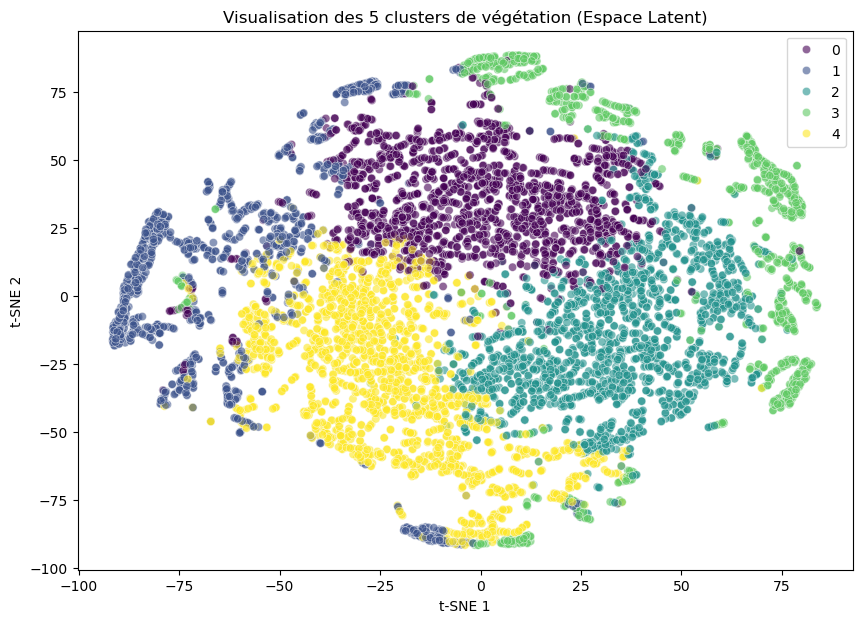

In [100]:
from sklearn.manifold import TSNE
import seaborn as sns

def plot_clusters(model, dataloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    latent_features = []
    labels = []
    
    print("Extraction des caractéristiques latentes...")
    with torch.no_grad():
        for data, _ in dataloader:
            data = data.to(device)
            z, q = model(data)
            
            # On prend le cluster avec la probabilité la plus haute
            cluster_preds = torch.argmax(q, dim=1)
            
            latent_features.append(z.cpu().numpy())
            labels.append(cluster_preds.cpu().numpy())
            
    latent_features = np.concatenate(latent_features, axis=0)
    labels = np.concatenate(labels, axis=0)
    
    # Réduction de dimension t-SNE (64D -> 2D)
    print("Calcul du t-SNE (cela peut prendre une minute)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    z_2d = tsne.fit_transform(latent_features)
    
    # Affichage
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=z_2d[:,0], y=z_2d[:,1], hue=labels, palette='viridis', legend='full', alpha=0.6)
    plt.title(f"Visualisation des {len(np.unique(labels))} clusters de végétation (Espace Latent)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

# Utilisation :
plot_clusters(model_final, dataloader_veg)

In [82]:
def generate_voted_vegetation_map(model, img_tensor, mask_tensor, n_clusters=N_CLUSTERS, patch_size=PATCH_SIZE, stride=STRIDE):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    C, H, W = img_tensor.shape
    vote_cube = np.zeros((n_clusters, H, W), dtype=np.uint16)

    print("Génération de la carte filtrée par le masque de végétation...")
    with torch.no_grad():
        for i in range(0, H - patch_size + 1, stride):
            for j in range(0, W - patch_size + 1, stride):
                
                patch = img_tensor[:, i:i+patch_size, j:j+patch_size].unsqueeze(0).to(device)
                _, q = model(patch)
                cluster_idx = torch.argmax(q, dim=1).item()
                
                # On vote
                vote_cube[cluster_idx, i:i+patch_size, j:j+patch_size] += 1

    # Application du vote majoritaire
    final_map = np.argmax(vote_cube, axis=0).astype(np.uint8)
    
    # APPLICATION DU MASQUE FINAL : 
    # Tous les pixels qui ne sont pas de la végétation dans le masque original (ex: valeur 0)
    # reçoivent une valeur de "No Data" (ex: 255)
    final_map[mask_tensor == 0] = 255 
    
    return final_map

# Exécution avec votre masque original
map_vegetation_pure = generate_voted_vegetation_map(
    model_final, 
    img_veg_torch, 
    mask_veg_torch, # Votre masque 2D de végétation
    n_clusters=5
)

Génération de la carte filtrée par le masque de végétation...


KeyboardInterrupt: 

In [101]:
def generate_smooth_map(model, img_tensor, mask_tensor, patch_dataset, n_clusters=N_CLUSTERS, patch_size=PATCH_SIZE, stride=STRIDE):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    C, H, W = img_tensor.shape
    # Accumulateur de probabilités (au lieu de votes entiers)
    score_map = np.zeros((n_clusters, H, W), dtype=np.float32)
    # Accumulateur de poids (pour normaliser les zones où les patchs se chevauchent)
    weight_sum = np.zeros((H, W), dtype=np.float32)
    
    # 1. Création d'une fenêtre de pondération (Gaussienne 2D)
    # Cela donne plus de poids au centre du patch pour éviter les effets de bordure
    def gaussian_2d(shape, sigma=1):
        m, n = [(ss - 1.) / 2. for ss in shape]
        y, x = np.ogrid[-m:m + 1, -n:n + 1]
        h = np.exp(-(x * x + y * y) / (2. * sigma * sigma))
        return h / h.max()

    window = gaussian_2d((patch_size, patch_size), sigma=patch_size/2)

    print("Génération de la carte lisse par pondération gaussienne...")
    with torch.no_grad():
        for (i, j) in patch_dataset.positions :
                
            patch = img_tensor[:, i:i+patch_size, j:j+patch_size].unsqueeze(0).to(device)
            _, q = model(patch) # q est la distribution de probabilité (Batch, 5)
                
                # On distribue les probabilités sur toute la surface du patch 
                # multipliées par le poids de la fenêtre
            q_values = q.squeeze(0).cpu().numpy() # Shape (5,)
            for c in range(n_clusters):
                score_map[c, i:i+patch_size, j:j+patch_size] += q_values[c] * window

                # On garde trace du cumul des poids pour la normalisation finale
            weight_sum[i:i+patch_size, j:j+patch_size] += window

    valid_mask = weight_sum > 0
    for k in range(n_clusters):
        score_map[k][valid_mask] /= weight_sum[valid_mask]

        # 2. Election finale par Argmax sur les scores accumulés
    final_map = np.argmax(score_map, axis=0).astype(float)

    # 3. Pixels hors patch valide → -1
    final_map[weight_sum == 0] = -1

    # 4. Application du masque noir (hors végétation)
    final_map[mask_tensor.cpu().numpy() == 0] = -1
    
    return final_map

map_vegetation_pure = generate_smooth_map(
    model_final, 
    img_veg_torch, 
    mask_veg_torch, # Votre masque 2D de végétation
    veggie_ds,
    stride=4
)

Génération de la carte lisse par pondération gaussienne...


C:\Users\arman\AppData\Local\Temp\ipykernel_3192\3199097382.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis_colors = cm.get_cmap('viridis', n_clusters)(np.linspace(0, 1, n_clusters))


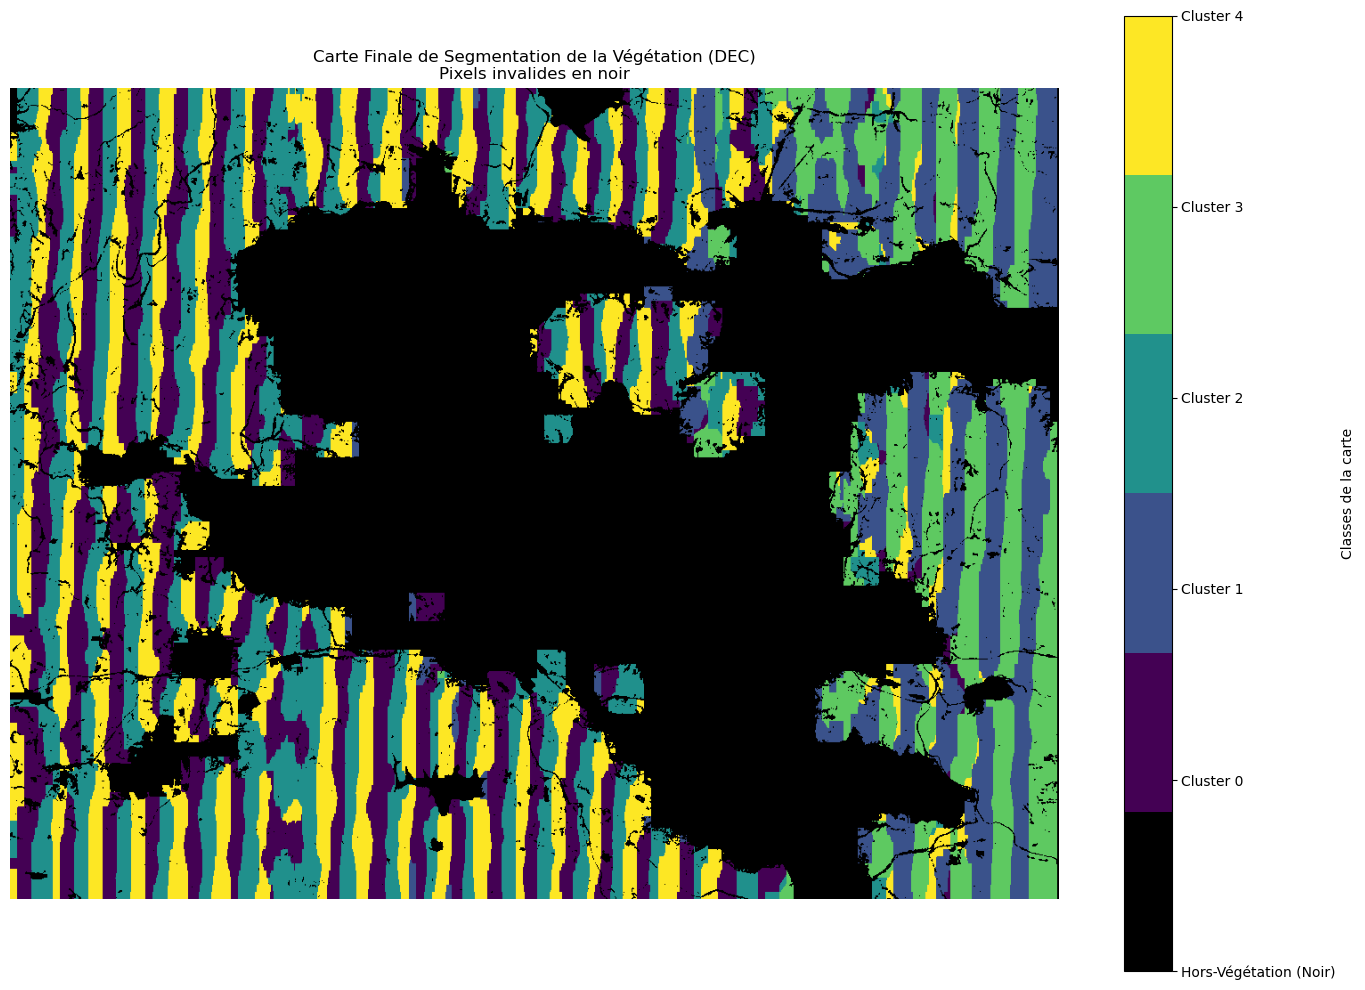

In [102]:
def plot_final_map_with_mask(clustered_map, mask_2d, n_clusters=N_CLUSTERS):
    """
    Affiche la carte de segmentation avec les pixels invalides en noir.
    """
    plt.figure(figsize=(14, 10))
    
    # 1. Préparation des données : on crée une copie pour ne pas modifier l'original
    display_map = clustered_map.copy().astype(float)
    
    # 2. On utilise le masque binaire pour forcer les zones hors-végétation à -1
    # Assurez-vous que mask_2d a les mêmes dimensions que clustered_map
    display_map[mask_2d == 0] = -1
    
    # 3. Création d'une colormap personnalisée : Noir pour -1, Viridis pour 0-4
    # On récupère 5 couleurs de la palette viridis
    viridis_colors = cm.get_cmap('viridis', n_clusters)(np.linspace(0, 1, n_clusters))
    
    # On ajoute le noir (RGB 0,0,0) au début de la liste des couleurs
    black_color = np.array([[0, 0, 0, 1]]) 
    new_colors = np.vstack([black_color, viridis_colors])
    custom_cmap = ListedColormap(new_colors)

    # 4. Affichage
    # vmin=-1 permet de caler le noir sur la valeur -1
    im = plt.imshow(display_map, cmap=custom_cmap, vmin=-1, vmax=n_clusters-1)
    
    # 5. Configuration de la barre de légende
    # On définit les ticks pour inclure "Invalide"
    ticks = np.arange(-1, n_clusters)
    cbar = plt.colorbar(im, ticks=ticks)
    cbar.set_label('Classes de la carte')
    
    # Étiquettes de la légende
    labels = ['Hors-Végétation (Noir)'] + [f'Cluster {i}' for i in range(n_clusters)]
    cbar.ax.set_yticklabels(labels)

    plt.title("Carte Finale de Segmentation de la Végétation (DEC)\nPixels invalides en noir")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Appel de la fonction
# Note : passez bien votre masque binaire (veg_mask_2d ou mask_torch) en deuxième argument
plot_final_map_with_mask(map_vegetation_pure, veg_mask_2d, n_clusters=5)